# Нейронная сеть Хопфилда для прогнозирования финансовых показателей

**Задание №4:**
- **Вход НС:** Некоторый набор финансовых показателей (курсы акций, валют, цены на сырьё).
- **На выходе НС:** Предсказание на **L** шагов вперёд одного из показателей.
- **Изменяемые параметры:** `M` — ширина окна наблюдения, `D` — глубина задержек, `Ns` — число элементов в скрытом слое.

**Архитектура:** Modern Hopfield Network (непрерывная версия) реализована через TensorFlow/Keras.  
Сеть Хопфилда используется как ассоциативная память: окно исторических цен кодируется в «паттерн», а слой Хопфилда извлекает из обученной памяти наиболее близкое состояние, которое затем декодируется в прогноз.

---
**Параметры сети:**
| Параметр | Описание |
|----------|----------|
| `M` | Ширина окна наблюдения (кол-во дней в истории) |
| `D` | Глубина задержек (шаг дискретизации внутри окна) |
| `L` | Горизонт прогнозирования (кол-во дней вперёд) |
| `Ns` | Число нейронов в скрытом/ассоциативном слое |

## 1. Импорт библиотек и настройка GPU

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

# ── Настройка GPU (NVIDIA) ──────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f'✓ Найдено GPU: {len(gpus)}')
    for i, gpu in enumerate(gpus):
        print(f'  GPU {i}: {gpu.name}')
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print('✓ Память GPU будет выделяться по мере необходимости (memory growth)')
    except RuntimeError as e:
        print(f'⚠ Ошибка настройки памяти: {e}')
    tf.config.set_visible_devices(gpus[0], 'GPU')
    print(f'✓ Активный GPU: {gpus[0].name}')
else:
    print('⚠ GPU не найдено, используется CPU')

print(f'\nTensorFlow версия: {tf.__version__}')
print(f'Используемое устройство: {"GPU" if gpus else "CPU"}')

✓ Найдено GPU: 1
  GPU 0: /physical_device:GPU:0
✓ Память GPU будет выделяться по мере необходимости (memory growth)
✓ Активный GPU: /physical_device:GPU:0

TensorFlow версия: 2.20.0
Используемое устройство: GPU


## 2. Гиперпараметры эксперимента

In [8]:
# ── Базовые параметры (фиксируются при варьировании одного из параметров) ──
M       = 30    # Ширина окна наблюдения (дней)
D       = 1     # Глубина задержек (шаг выборки внутри окна)
L       = 5     # Горизонт прогнозирования (дней вперёд)
Ns      = 128   # Число нейронов в скрытом (ассоциативном) слое Хопфилда
BETA    = 1.0   # Температурный параметр softmax в сети Хопфилда
EPOCHS  = 60    # Эпохи обучения
BATCH   = 32    # Размер мини-батча

print('Параметры эксперимента:')
print(f'  M  = {M}  (ширина окна)')
print(f'  D  = {D}  (глубина задержек)')
print(f'  L  = {L}  (горизонт прогноза)')
print(f'  Ns = {Ns} (нейронов в слое Хопфилда)')
print(f'  β  = {BETA} (температура)')

Параметры эксперимента:
  M  = 30  (ширина окна)
  D  = 1  (глубина задержек)
  L  = 5  (горизонт прогноза)
  Ns = 128 (нейронов в слое Хопфилда)
  β  = 1.0 (температура)


## 3. Загрузка финансовых данных

Используем котировки золота (GC=F) как основной прогнозируемый показатель.

Загружено строк: 1572


,gold,silver
Date,,
2020-01-02,1524.500000,17.966000
2020-01-03,1549.199951,18.068001
2020-01-06,1566.199951,18.097000
2020-01-07,1571.800049,18.316000
2020-01-08,1557.400024,18.087999


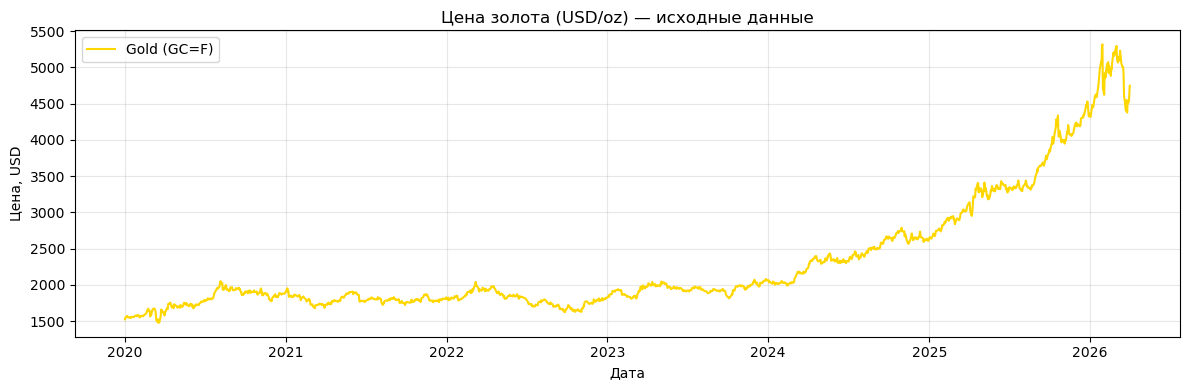

In [9]:
tickers = ['GC=F', 'SI=F']
raw = yf.download(tickers, start='2020-01-01', progress=False)

gold   = raw['Close']['GC=F']
silver = raw['Close']['SI=F']

data = pd.DataFrame({'gold': gold, 'silver': silver}).dropna()
print(f'Загружено строк: {len(data)}')
display(data.head())

plt.figure(figsize=(12, 4))
plt.plot(data.index, data['gold'], label='Gold (GC=F)', color='gold')
plt.title('Цена золота (USD/oz) — исходные данные')
plt.xlabel('Дата')
plt.ylabel('Цена, USD')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Предобработка данных

Нормализация + формирование скользящих окон с параметрами M, D, L.

In [17]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data[['gold']])

def build_dataset(series, M, D, L):
    """Формирует пары (X, y): X — скользящее окно, y — значение через L шагов.
    
    Args:
        series: нормализованный массив цен (ожидается 2D или 1D)
        M: ширина окна наблюдения (временной интервал)
        D: шаг задержки (стрейд)
        L: горизонт прогнозирования
    """
    X, y = [], []
    n = len(series)
    
    # Убедимся, что series — numpy массив для корректной индексации
    if not isinstance(series, np.ndarray):
        series = np.array(series)

    for i in range(M, n - L):
        # ИСПРАВЛЕНИЕ: Убрали (i - M) % D, чтобы длина окна была постоянной
        start_idx = i - M 
        indices   = list(range(start_idx, i, D))
        
        # Проверка на случай, если indices пуст (защита от ошибок при больших D)
        if not indices:
            continue
            
        window = series[indices].flatten()
        
        # Обработка target в зависимости от размерности series
        if series.ndim == 1:
            target = series[i + L]
        else:
            target = series[i + L, 0]
            
        X.append(window)
        y.append(target)
        
    # Теперь все элементы в X имеют одинаковую длину, ошибка исчезнет
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X, y = build_dataset(data_scaled, M, D, L)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f'Обучающая выборка:  {X_train.shape[0]} образцов, признаков: {X_train.shape[1]}')
print(f'Тестовая выборка:   {X_test.shape[0]} образцов')

Обучающая выборка:  1229 образцов, признаков: 30
Тестовая выборка:   308 образцов


## 5. Архитектура: Modern Hopfield Network

### Теоретическая база

**Классическая сеть Хопфилда** (Hopfield, 1982) — это рекуррентная сеть с симметричными весами, используемая как ассоциативная память. Энергетическая функция:

$$E = -\frac{1}{2} \sum_{i,j} w_{ij} s_i s_j$$

**Modern Hopfield Networks** (Ramsauer et al., 2020) — непрерывная версия с экспоненциальной ёмкостью памяти. Правило обновления состояния:

$$\mathbf{x}^{\text{new}} = X^T \cdot \text{softmax}(\beta \cdot X \cdot \mathbf{x})$$

где $X$ — матрица хранимых паттернов, $\beta$ — обратная температура.

**Ключевое свойство:** один шаг Modern Hopfield = механизм **cross-attention** (как в трансформерах), что позволяет нативно интегрировать его в Keras как Custom Layer.

**Схема модели для прогнозирования:**
```
Вход [batch, n_features]
  → Dense (Encoder) [batch, Ns]          # Кодирование запроса
  → HopfieldLayer (Ассоциативная память) # Извлечение из памяти
  → Dense (Decoder) [batch, 1]           # Декодирование прогноза
```

In [11]:
class HopfieldLayer(layers.Layer):
    """Modern Hopfield Layer (непрерывная ассоциативная память).
    
    Реализует один шаг обновления состояния Modern Hopfield Network:
        new_state = stored_patterns^T · softmax(β · stored_patterns · query)
    
    Хранимые паттерны (stored_patterns) — обучаемая матрица весов.
    Параметры:
        memory_size:  число хранимых паттернов (ёмкость памяти)
        pattern_dim:  размерность каждого паттерна
        beta:         температурный параметр (β → ∞ даёт классический Хопфилд)
    """

    def __init__(self, memory_size: int, pattern_dim: int, beta: float = 1.0, **kwargs):
        super().__init__(**kwargs)
        self.memory_size = memory_size
        self.pattern_dim = pattern_dim
        self.beta        = beta

    def build(self, input_shape):
        # Матрица хранимых паттернов [memory_size, pattern_dim]
        self.stored_patterns = self.add_weight(
            name='stored_patterns',
            shape=(self.memory_size, self.pattern_dim),
            initializer='glorot_uniform',
            trainable=True
        )
        super().build(input_shape)

    def call(self, query):
        """
        query: [batch, pattern_dim]
        Returns: [batch, pattern_dim] — результат ассоциативного поиска
        """
        # Сходство запроса с каждым паттерном: [batch, memory_size]
        similarities = self.beta * tf.matmul(query, self.stored_patterns, transpose_b=True)
        # Веса softmax
        attention = tf.nn.softmax(similarities, axis=-1)  # [batch, memory_size]
        # Взвешенная сумма паттернов — ассоциативный отклик
        retrieved = tf.matmul(attention, self.stored_patterns)  # [batch, pattern_dim]
        return retrieved

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'memory_size': self.memory_size,
                    'pattern_dim': self.pattern_dim,
                    'beta': self.beta})
        return cfg


def build_hopfield_model(n_features: int, Ns: int = 128, beta: float = 1.0) -> Model:
    """Строит модель на основе Modern Hopfield Network.
    
    Args:
        n_features: размерность входного вектора (ширина окна / D)
        Ns:         размер скрытого слоя (=pattern_dim=memory_size)
        beta:       температурный параметр Хопфилда
    Returns:
        Скомпилированная Keras-модель
    """
    inp     = layers.Input(shape=(n_features,), name='input')
    # Encoder: проецируем вход в пространство паттернов
    encoded = layers.Dense(Ns, activation='tanh', name='encoder')(inp)
    # Hopfield Layer: ассоциативный поиск в памяти
    hopf    = HopfieldLayer(memory_size=Ns, pattern_dim=Ns, beta=beta, name='hopfield')(encoded)
    # Residual connection + нормализация
    merged  = layers.Add(name='residual')([encoded, hopf])
    normed  = layers.LayerNormalization(name='layer_norm')(merged)
    # Decoder: из ассоциированного состояния → скалярный прогноз
    out     = layers.Dense(1, activation='linear', name='output')(normed)

    model = Model(inputs=inp, outputs=out, name='HopfieldNet')
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss='mse',
                  metrics=['mae'])
    return model

# Демонстрация архитектуры с базовыми параметрами
demo_model = build_hopfield_model(n_features=X_train.shape[1], Ns=Ns, beta=BETA)
demo_model.summary()

I0000 00:00:1775049116.579647    1360 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5527 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:2b:00.0, compute capability: 8.9


Model: "HopfieldNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 30)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder (Dense)     │ (None, 128)       │      3,968 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hopfield            │ (None, 128)       │     16,384 │ encoder[0][0]     │
│ (HopfieldLayer)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual (Add)      │ (None, 128)       │          0 │ encoder[0][0],    │
│                     │                   │            │ hopfield[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_norm          │ (None, 128)       │        256 │ residual[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        129 │ layer_norm[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,737 (81.00 KB)

 Trainable params: 20,737 (81.00 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Базовое обучение модели

Epoch 1/60


2026-04-01 16:11:58.284437: I external/local_xla/xla/service/service.cc:163] XLA service 0x73653c006660 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-01 16:11:58.284479: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Ti, Compute Capability 8.9
2026-04-01 16:11:58.329669: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-01 16:11:58.454699: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700
2026-04-01 16:11:58.513795: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 16:11:58.513854: 

26/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0906 - mae: 0.8510 

I0000 00:00:1775049122.905786    1663 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.8695 - mae: 0.7297

2026-04-01 16:12:05.531072: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 16:12:05.531128: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 16:12:06.646719: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_53', 28 bytes spill stores, 28 bytes spill loads

2026-04-01 16:12:06.751507: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : R

39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - loss: 0.3672 - mae: 0.4364 - val_loss: 0.1793 - val_mae: 0.3685
Epoch 2/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0108 - mae: 0.0789 - val_loss: 0.1970 - val_mae: 0.3957
Epoch 3/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0048 - mae: 0.0516 - val_loss: 0.1865 - val_mae: 0.3838
Epoch 4/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0043 - mae: 0.0490 - val_loss: 0.1840 - val_mae: 0.3822
Epoch 5/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0037 - mae: 0.0445 - val_loss: 0.1871 - val_mae: 0.3869
Epoch 6/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0034 - mae: 0.0435 - val_loss: 0.1693 - val_mae: 0.3655
Epoch 7/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0032 - mae: 0.0421 - val_loss: 0.1723 - val_mae: 0.3694
Epoch 8/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0031 - mae: 0.0414 - val_loss: 0.1698 - val_mae: 0.3684
Epoch 9/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0029 - mae: 0.0397 -

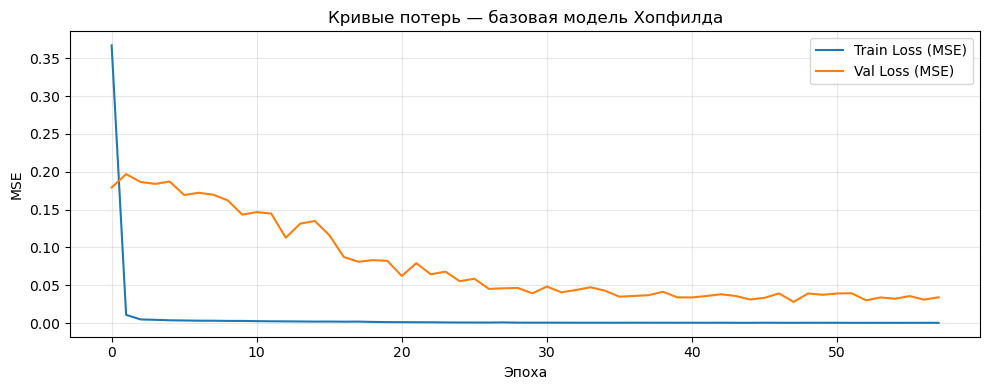

In [12]:
def train_model(model, X_train, y_train, X_val, y_val,
                epochs=60, batch_size=32, early_stop=True, patience=10, verbose=0):
    """Обучение модели с опциональным EarlyStopping."""
    callbacks = []
    if early_stop:
        callbacks.append(EarlyStopping(monitor='val_loss', patience=patience,
                                       restore_best_weights=True, verbose=0))
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose
    )
    return history


with tf.device('/GPU:0' if gpus else '/CPU:0'):
    base_model   = build_hopfield_model(X_train.shape[1], Ns=Ns, beta=BETA)
    base_history = train_model(base_model, X_train, y_train, X_test, y_test,
                               epochs=EPOCHS, batch_size=BATCH, early_stop=True, verbose=1)

train_loss = base_history.history['loss']
val_loss   = base_history.history['val_loss']
print(f'\nЛучший val_loss: {min(val_loss):.6f}')

# ── График кривых обучения ──────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(train_loss, label='Train Loss (MSE)')
plt.plot(val_loss,   label='Val Loss (MSE)')
plt.title('Кривые потерь — базовая модель Хопфилда')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Прогнозирование и визуализация результатов

RMSE (train): 105.34 USD
RMSE (test):  642.89 USD


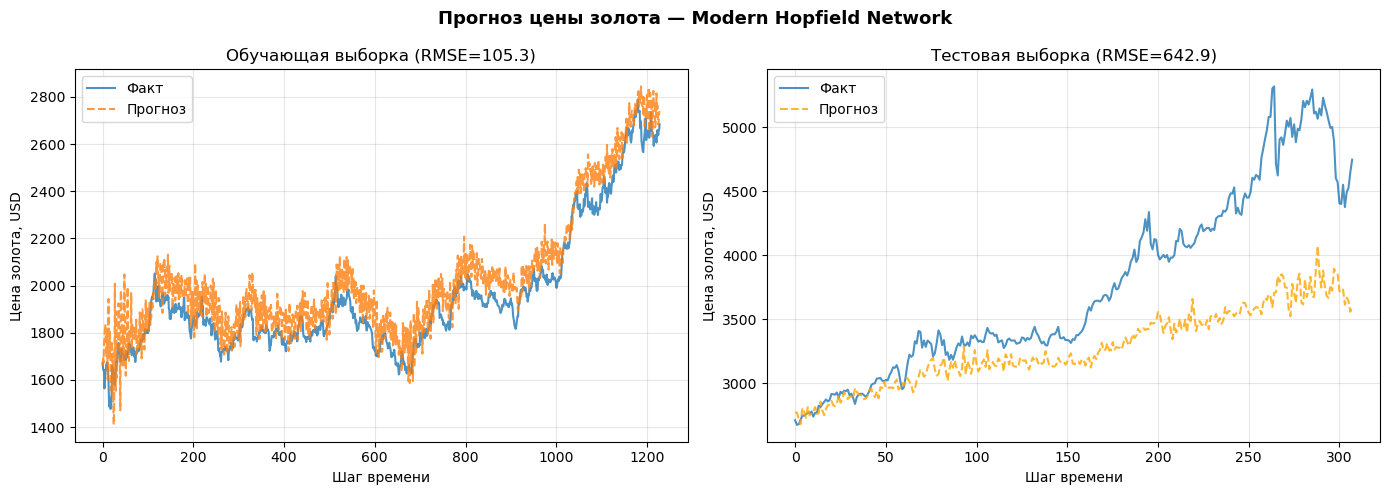

In [13]:
y_pred_train = base_model.predict(X_train, verbose=0).flatten()
y_pred_test  = base_model.predict(X_test,  verbose=0).flatten()

# Обратное масштабирование
def inverse(arr):
    return scaler.inverse_transform(arr.reshape(-1, 1)).flatten()

y_train_real = inverse(y_train)
y_test_real  = inverse(y_test)
y_pred_train_real = inverse(y_pred_train)
y_pred_test_real  = inverse(y_pred_test)

rmse_train = np.sqrt(mean_squared_error(y_train_real, y_pred_train_real))
rmse_test  = np.sqrt(mean_squared_error(y_test_real,  y_pred_test_real))
print(f'RMSE (train): {rmse_train:.2f} USD')
print(f'RMSE (test):  {rmse_test:.2f} USD')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(y_train_real,       label='Факт',  alpha=0.8)
axes[0].plot(y_pred_train_real,  label='Прогноз', alpha=0.8, linestyle='--')
axes[0].set_title(f'Обучающая выборка (RMSE={rmse_train:.1f})')
axes[0].set_xlabel('Шаг времени')
axes[0].set_ylabel('Цена золота, USD')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(y_test_real,       label='Факт',  alpha=0.8)
axes[1].plot(y_pred_test_real,  label='Прогноз', alpha=0.8, linestyle='--', color='orange')
axes[1].set_title(f'Тестовая выборка (RMSE={rmse_test:.1f})')
axes[1].set_xlabel('Шаг времени')
axes[1].set_ylabel('Цена золота, USD')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Прогноз цены золота — Modern Hopfield Network', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Зависимость функции потерь от параметров M, D, L, Ns

По очереди варьируем **один параметр**, остальные фиксируются на базовых значениях.

In [14]:
def run_sweep(param_name, param_values, base_M=30, base_D=1, base_L=5, base_Ns=128,
              epochs=40, batch_size=32):
    """Запускает серию экспериментов, варьируя один параметр.
    
    Returns:
        dict: param_value → {'train_loss': [...], 'val_loss': [...],
                              'final_train': float, 'final_val': float}
    """
    results = {}
    for val in param_values:
        cur_M  = val if param_name == 'M'  else base_M
        cur_D  = val if param_name == 'D'  else base_D
        cur_L  = val if param_name == 'L'  else base_L
        cur_Ns = val if param_name == 'Ns' else base_Ns

        Xi, yi = build_dataset(data_scaled, cur_M, cur_D, cur_L)
        if len(Xi) < 50:
            print(f'  [{param_name}={val}] Недостаточно данных, пропуск')
            continue
        sp = int(len(Xi) * 0.8)
        Xtr, Xte = Xi[:sp], Xi[sp:]
        ytr, yte = yi[:sp], yi[sp:]

        with tf.device('/GPU:0' if gpus else '/CPU:0'):
            model = build_hopfield_model(Xtr.shape[1], Ns=cur_Ns, beta=BETA)
            hist  = train_model(model, Xtr, ytr, Xte, yte,
                                epochs=epochs, batch_size=batch_size,
                                early_stop=False, verbose=0)

        tl = hist.history['loss']
        vl = hist.history['val_loss']
        results[val] = {
            'train_loss':  tl,
            'val_loss':    vl,
            'final_train': tl[-1],
            'final_val':   vl[-1]
        }
        print(f'  [{param_name}={val:>4}] train_loss={tl[-1]:.5f}  val_loss={vl[-1]:.5f}')
    return results


def plot_sweep_curves(results, param_name, title_suffix=''):
    """Строит кривые обучения и итоговый bar-chart для одного sweep."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cmap   = plt.get_cmap('viridis', len(results))
    values = sorted(results.keys())

    for idx, v in enumerate(values):
        color = cmap(idx)
        axes[0].plot(results[v]['train_loss'], color=color, linestyle='--',  alpha=0.7, linewidth=1)
        axes[0].plot(results[v]['val_loss'],   color=color, label=f'{param_name}={v}', linewidth=1.5)

    axes[0].set_title(f'Кривые потерь при варьировании {param_name}{title_suffix}')
    axes[0].set_xlabel('Эпоха')
    axes[0].set_ylabel('MSE')
    axes[0].legend(fontsize=8, ncol=2)
    axes[0].grid(alpha=0.3)

    final_train = [results[v]['final_train'] for v in values]
    final_val   = [results[v]['final_val']   for v in values]
    x_pos = np.arange(len(values))
    w = 0.35
    axes[1].bar(x_pos - w/2, final_train, w, label='Train Loss', alpha=0.8)
    axes[1].bar(x_pos + w/2, final_val,   w, label='Val Loss',   alpha=0.8)
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels([str(v) for v in values])
    axes[1].set_title(f'Итоговые потери vs {param_name}')
    axes[1].set_xlabel(param_name)
    axes[1].set_ylabel('MSE (финальная эпоха)')
    axes[1].legend()
    axes[1].grid(alpha=0.3, axis='y')

    plt.suptitle(f'Влияние параметра {param_name} на функцию потерь', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 8.1 Варьирование M — ширины окна наблюдения

Sweep по M (D=1, L=5, Ns=128)


2026-04-01 16:12:23.411092: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 16:12:23.411148: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 16:12:24.545059: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_25', 132 bytes spill stores, 132 bytes spill loads

2026-04-01 16:12:34.967463: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning :

  [M=   5] train_loss=0.00051  val_loss=0.08863


2026-04-01 16:12:34.082579: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 16:12:34.082635: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 16:12:34.082648: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 16:12:35.139608: I external/l

  [M=  10] train_loss=0.00065  val_loss=0.07331


...

  [M=  20] train_loss=0.00035  val_loss=0.01130
  [M=  30] train_loss=0.00048  val_loss=0.02127


2026-04-01 16:13:10.841531: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 16:13:11.625808: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_599', 16 bytes spill stores, 16 bytes spill loads

2026-04-01 16:13:11.630946: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_599', 16 bytes spill stores, 16 bytes spill loads

2026-04-01 16:13:11.752666: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_599', 416 byte

  [M=  50] train_loss=0.00090  val_loss=0.00324


2026-04-01 16:13:22.874485: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 16:13:23.434338: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_599', 16 bytes spill stores, 16 bytes spill loads

2026-04-01 16:13:23.728660: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_599', 240 bytes spill stores, 240 bytes spill loads



  [M=  70] train_loss=0.00079  val_loss=0.01545


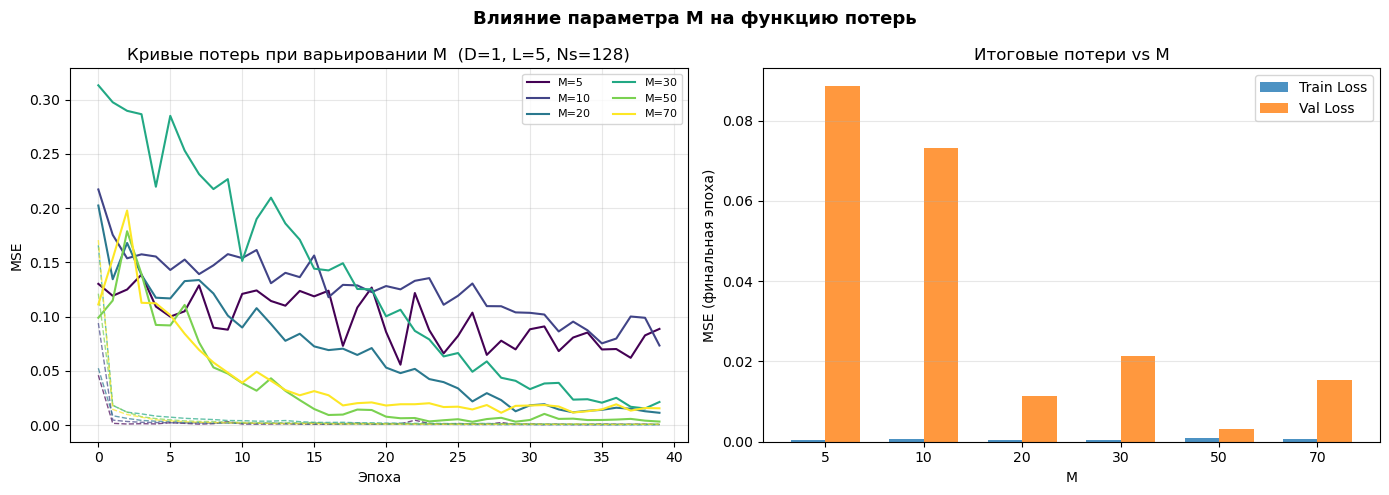

In [15]:
M_values = [5, 10, 20, 30, 50, 70]
print(f'Sweep по M (D={D}, L={L}, Ns={Ns})')
results_M = run_sweep('M', M_values, base_D=D, base_L=L, base_Ns=Ns, epochs=40)
plot_sweep_curves(results_M, 'M', f'  (D={D}, L={L}, Ns={Ns})')

### 8.2 Варьирование D — глубины задержек

Sweep по D (M=30, L=5, Ns=128)
  [D=   1] train_loss=0.00028  val_loss=0.00646
  [D=   2] train_loss=0.00061  val_loss=0.05323
  [D=   3] train_loss=0.00122  val_loss=0.10106
  [D=   5] train_loss=0.00070  val_loss=0.08696
  [D=   7] train_loss=0.00054  val_loss=0.06087
  [D=  10] train_loss=0.00080  val_loss=0.09212


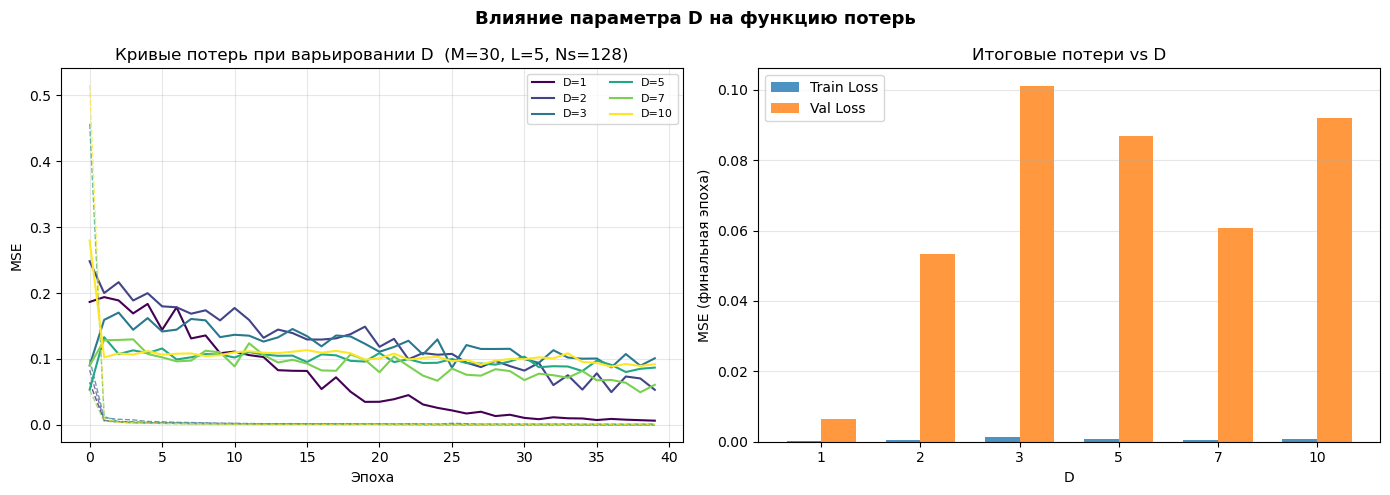

In [18]:
D_values = [1, 2, 3, 5, 7, 10]
print(f'Sweep по D (M={M}, L={L}, Ns={Ns})')
results_D = run_sweep('D', D_values, base_M=M, base_L=L, base_Ns=Ns, epochs=40)
plot_sweep_curves(results_D, 'D', f'  (M={M}, L={L}, Ns={Ns})')

### 8.3 Варьирование L — горизонта прогнозирования

Sweep по L (M=30, D=1, Ns=128)
  [L=   1] train_loss=0.00024  val_loss=0.00336
  [L=   3] train_loss=0.00051  val_loss=0.03579
  [L=   5] train_loss=0.00035  val_loss=0.00248


2026-04-01 16:20:52.717401: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 16:20:52.717456: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 16:20:53.805245: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_53', 28 bytes spill stores, 28 bytes spill loads

2026-04-01 16:20:53.850057: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : R

  [L=  10] train_loss=0.00060  val_loss=0.00381


2026-04-01 16:21:05.201509: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 16:21:05.201561: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 16:21:05.677065: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_53', 28 bytes spill stores, 28 bytes spill loads

2026-04-01 16:21:05.994750: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : R

  [L=  15] train_loss=0.00082  val_loss=0.04447


2026-04-01 16:21:16.848310: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 16:21:16.848364: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 16:21:17.901359: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_53', 28 bytes spill stores, 28 bytes spill loads

2026-04-01 16:21:18.040359: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : R

  [L=  20] train_loss=0.00117  val_loss=0.02650


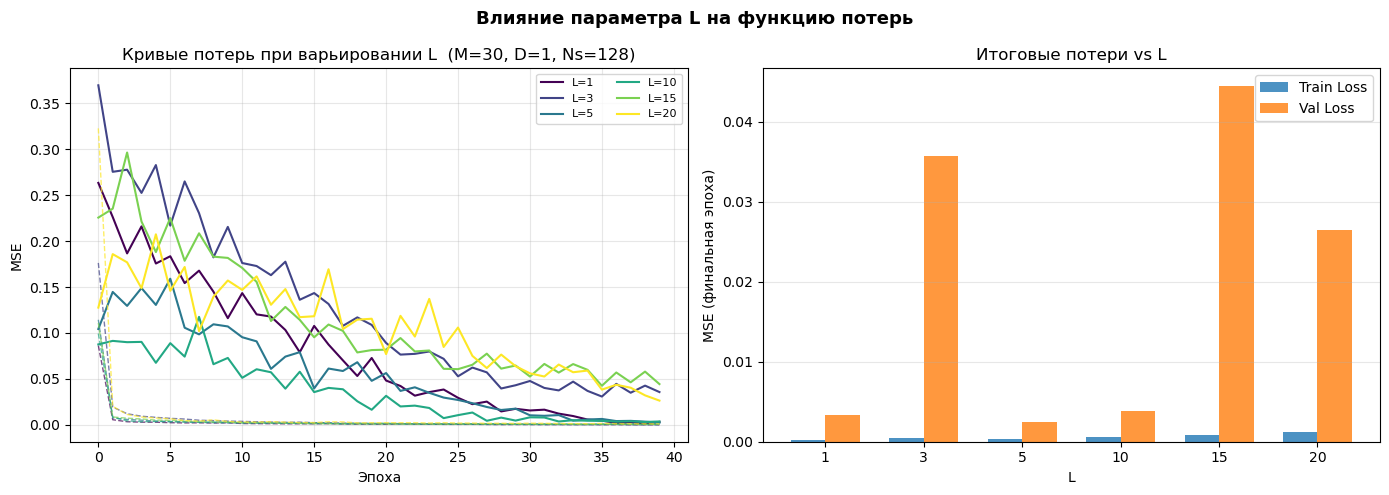

In [19]:
L_values = [1, 3, 5, 10, 15, 20]
print(f'Sweep по L (M={M}, D={D}, Ns={Ns})')
results_L = run_sweep('L', L_values, base_M=M, base_D=D, base_Ns=Ns, epochs=40)
plot_sweep_curves(results_L, 'L', f'  (M={M}, D={D}, Ns={Ns})')

### 8.4 Варьирование Ns — числа нейронов в слое Хопфилда

Sweep по Ns (M=30, D=1, L=5)
  [Ns=  16] train_loss=0.00195  val_loss=0.03242
  [Ns=  32] train_loss=0.00054  val_loss=0.08242
  [Ns=  64] train_loss=0.00050  val_loss=0.00236
  [Ns= 128] train_loss=0.00040  val_loss=0.01579
  [Ns= 256] train_loss=0.00053  val_loss=0.01456
  [Ns= 512] train_loss=0.00044  val_loss=0.02238


2026-04-01 16:29:25.975278: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 16:29:26.194753: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_183', 4 bytes spill stores, 4 bytes spill loads

2026-04-01 16:29:27.064111: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_603', 520 bytes spill stores, 520 bytes spill loads



  [Ns=1024] train_loss=0.00099  val_loss=0.10750


2026-04-01 16:29:42.629296: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 16:29:43.204805: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_565', 132 bytes spill stores, 132 bytes spill loads

2026-04-01 16:29:43.226871: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_183', 4 bytes spill stores, 4 bytes spill loads

2026-04-01 16:29:43.729692: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_148', 332 byte

  [Ns=2048] train_loss=0.00108  val_loss=0.09115


2026-04-01 16:29:57.859152: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 16:29:58.683038: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_183', 4 bytes spill stores, 4 bytes spill loads

2026-04-01 16:29:58.780959: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_148', 340 bytes spill stores, 332 bytes spill loads

2026-04-01 16:29:58.810598: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_183', 60 bytes

  [Ns=4096] train_loss=0.00069  val_loss=0.08687


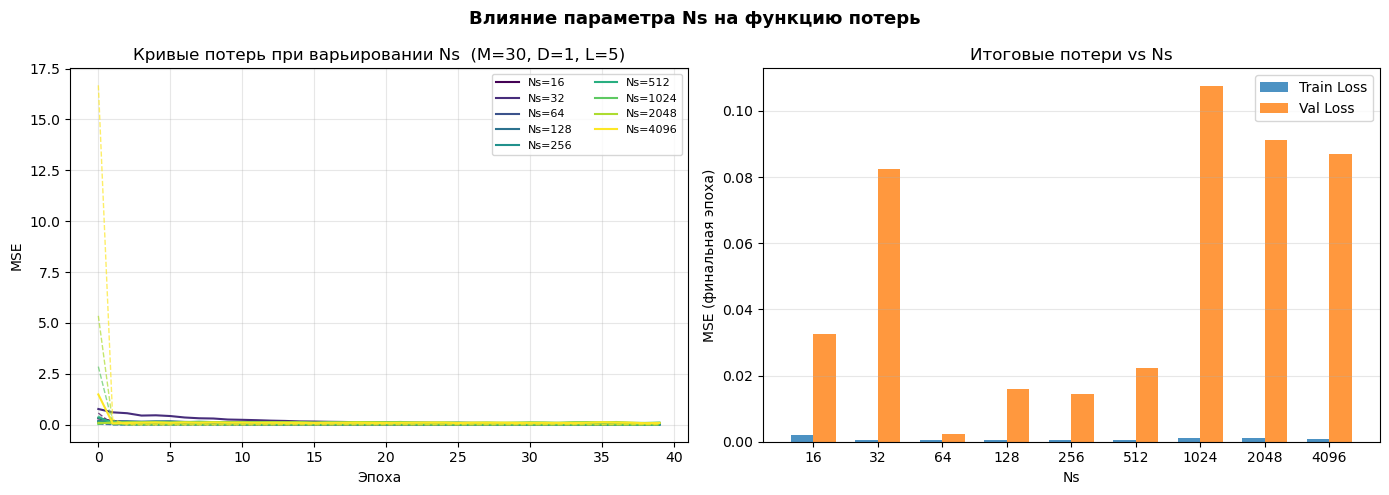

In [24]:
Ns_values = [16, 32, 64, 128, 256, 512, 1024, 2048, 4096]
print(f'Sweep по Ns (M={M}, D={D}, L={L})')
results_Ns = run_sweep('Ns', Ns_values, base_M=M, base_D=D, base_L=L, epochs=40)
plot_sweep_curves(results_Ns, 'Ns', f'  (M={M}, D={D}, L={L})')

## 9. Демонстрация переобучения

Чтобы вызвать переобучение, используем:
- **Очень большой Ns** (много параметров, много «паттернов памяти»)
- **Маленький объём обучающих данных** (M=5, малое окно → мало признаков и образцов)
- **Отсутствие ранней остановки** и большое число эпох

Параметры для демонстрации переобучения: M=10, Ns=4096, epochs=200
Обучающая выборка: 1245 образцов


2026-04-01 16:38:32.322652: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_148', 384 bytes spill stores, 324 bytes spill loads

2026-04-01 16:38:32.331368: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_565', 4 bytes spill stores, 4 bytes spill loads

2026-04-01 16:38:32.611286: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_183', 4 bytes spill stores, 4 bytes spill loads

2026-04-01 16:38:32.860234: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_148', 60 bytes spill stores, 60 bytes spill loads

2026-04-01 16:38:32.953493: I external/local_x

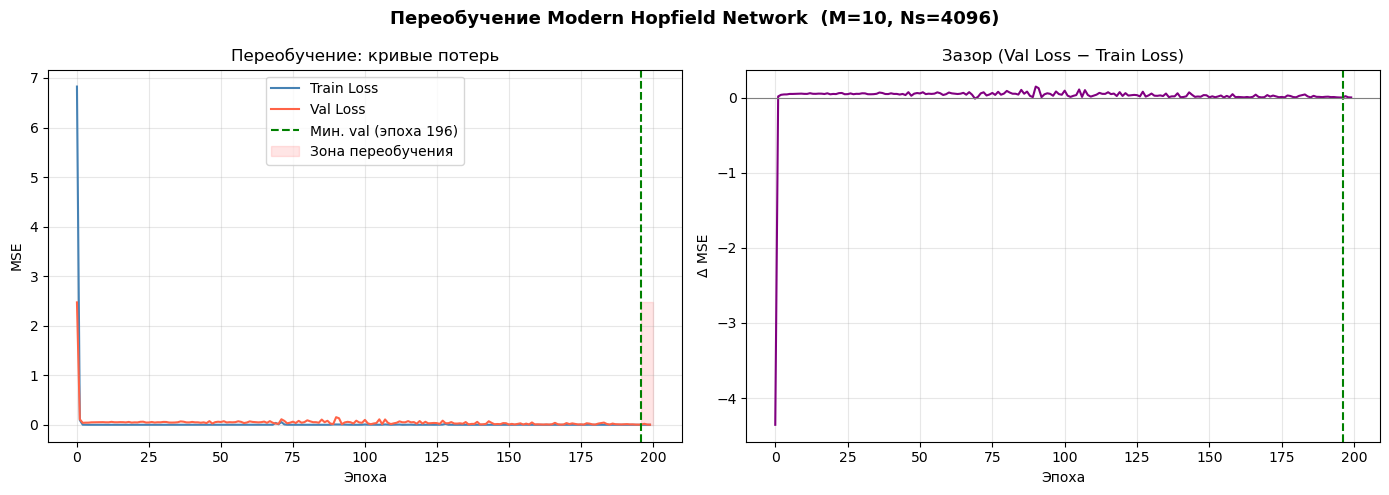


Минимальный val_loss на эпохе 196: 0.00315
Финальный train_loss: 0.00056  |  Финальный val_loss: 0.00337
Зазор переобучения: 0.00281


In [29]:
# Настройки, провоцирующие переобучение
M_of   = 10   # Маленькое окно
Ns_of  = 4096  # Гигантский скрытый слой
EPC_OF = 200  # Много эпох, без ранней остановки

X_of, y_of = build_dataset(data_scaled, M_of, D=1, L=L)
sp_of = int(len(X_of) * 0.8)
X_tr_of, X_te_of = X_of[:sp_of], X_of[sp_of:]
y_tr_of, y_te_of = y_of[:sp_of], y_of[sp_of:]

print(f'Параметры для демонстрации переобучения: M={M_of}, Ns={Ns_of}, epochs={EPC_OF}')
print(f'Обучающая выборка: {len(X_tr_of)} образцов')

with tf.device('/GPU:0' if gpus else '/CPU:0'):
    overfit_model   = build_hopfield_model(X_tr_of.shape[1], Ns=Ns_of, beta=BETA)
    overfit_history = train_model(overfit_model, X_tr_of, y_tr_of, X_te_of, y_te_of,
                                  epochs=EPC_OF, batch_size=BATCH,
                                  early_stop=False, verbose=0)

tl_of = overfit_history.history['loss']
vl_of = overfit_history.history['val_loss']

# ── Поиск точки начала переобучения ────────────────────────────────────────
best_val_epoch = int(np.argmin(vl_of))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Кривые потерь
axes[0].plot(tl_of, label='Train Loss', color='steelblue')
axes[0].plot(vl_of, label='Val Loss',   color='tomato')
axes[0].axvline(best_val_epoch, color='green', linestyle='--', linewidth=1.5,
                label=f'Мин. val (эпоха {best_val_epoch})')
axes[0].fill_betweenx([0, max(vl_of)], best_val_epoch, EPC_OF,
                       alpha=0.1, color='red', label='Зона переобучения')
axes[0].set_title('Переобучение: кривые потерь')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Зазор train/val по эпохам
gap = np.array(vl_of) - np.array(tl_of)
axes[1].plot(gap, color='purple')
axes[1].axvline(best_val_epoch, color='green', linestyle='--', linewidth=1.5)
axes[1].axhline(0, color='gray', linewidth=0.8)
axes[1].set_title('Зазор (Val Loss − Train Loss)')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Δ MSE')
axes[1].grid(alpha=0.3)

plt.suptitle(f'Переобучение Modern Hopfield Network  (M={M_of}, Ns={Ns_of})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nМинимальный val_loss на эпохе {best_val_epoch}: {min(vl_of):.5f}')
print(f'Финальный train_loss: {tl_of[-1]:.5f}  |  Финальный val_loss: {vl_of[-1]:.5f}')
print(f'Зазор переобучения: {vl_of[-1] - tl_of[-1]:.5f}')

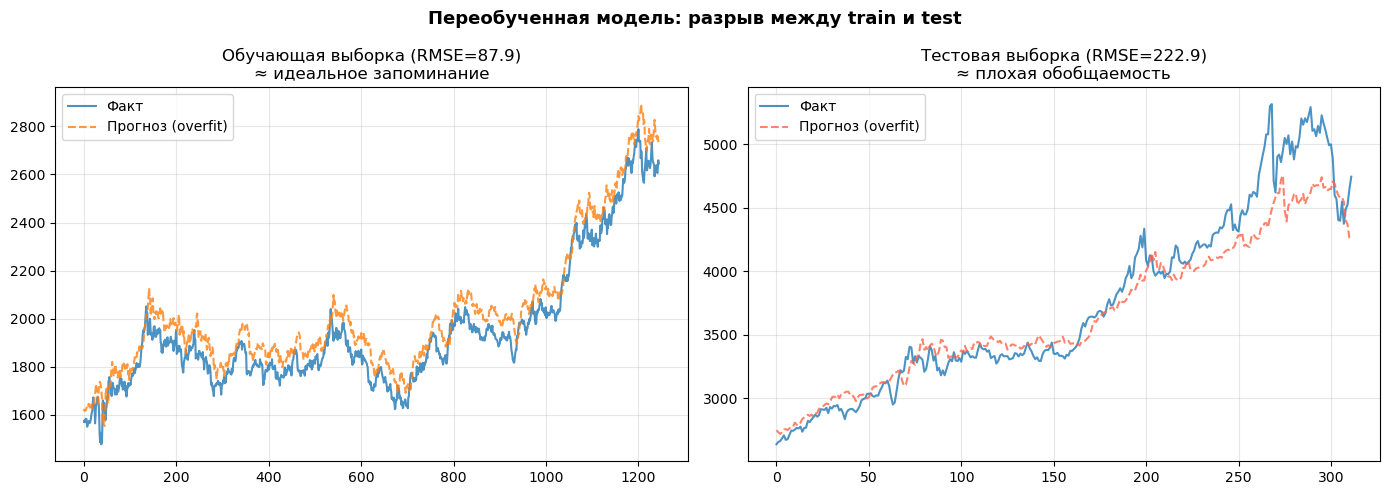

In [30]:
# Сравнение прогнозов: переобученная vs нормальная модель
y_pred_of_train = overfit_model.predict(X_tr_of, verbose=0).flatten()
y_pred_of_test  = overfit_model.predict(X_te_of, verbose=0).flatten()

def inv(arr):
    return scaler.inverse_transform(arr.reshape(-1, 1)).flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# На train — отличное совпадение (запомнила данные)
axes[0].plot(inv(y_tr_of), label='Факт', alpha=0.8)
axes[0].plot(inv(y_pred_of_train), label='Прогноз (overfit)', linestyle='--', alpha=0.8)
rmse_tr = np.sqrt(mean_squared_error(inv(y_tr_of), inv(y_pred_of_train)))
axes[0].set_title(f'Обучающая выборка (RMSE={rmse_tr:.1f})\n≈ идеальное запоминание')
axes[0].legend()
axes[0].grid(alpha=0.3)

# На test — плохое качество
axes[1].plot(inv(y_te_of), label='Факт', alpha=0.8)
axes[1].plot(inv(y_pred_of_test), label='Прогноз (overfit)', linestyle='--', alpha=0.8, color='tomato')
rmse_te = np.sqrt(mean_squared_error(inv(y_te_of), inv(y_pred_of_test)))
axes[1].set_title(f'Тестовая выборка (RMSE={rmse_te:.1f})\n≈ плохая обобщаемость')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Переобученная модель: разрыв между train и test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()